<a href="https://colab.research.google.com/github/ar11-miss/Gen-AI-3/blob/main/assignment03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model

In [2]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values between 0 and 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data: (60000, 784)
Testing data: (10000, 784)


Each MNIST image is:

28 × 28 = 784 pixels

In [3]:
input_img = layers.Input(shape=(784,))

# Encoder
encoded = layers.Dense(128, activation="relu")(input_img)
encoded = layers.Dense(64, activation="relu")(encoded)
latent = layers.Dense(32, activation="relu")(encoded)

# Decoder
decoded = layers.Dense(64, activation="relu")(latent)
decoded = layers.Dense(128, activation="relu")(decoded)
output_img = layers.Dense(784, activation="sigmoid")(decoded)

autoencoder = Model(input_img, output_img)

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history_ae = autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=256,
    validation_data=(x_test, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.2477 - val_loss: 0.1694
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1534 - val_loss: 0.1406
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1330 - val_loss: 0.1255
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1228 - val_loss: 0.1177
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1168 - val_loss: 0.1130
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1126 - val_loss: 0.1095
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1090 - val_loss: 0.1060
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1060 - val_loss: 0.1033
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1035 - val_loss: 0.1014
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1018 - val_loss: 0.1001
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1003 - val_loss: 0.0985
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [5]:
reconstructed_ae = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


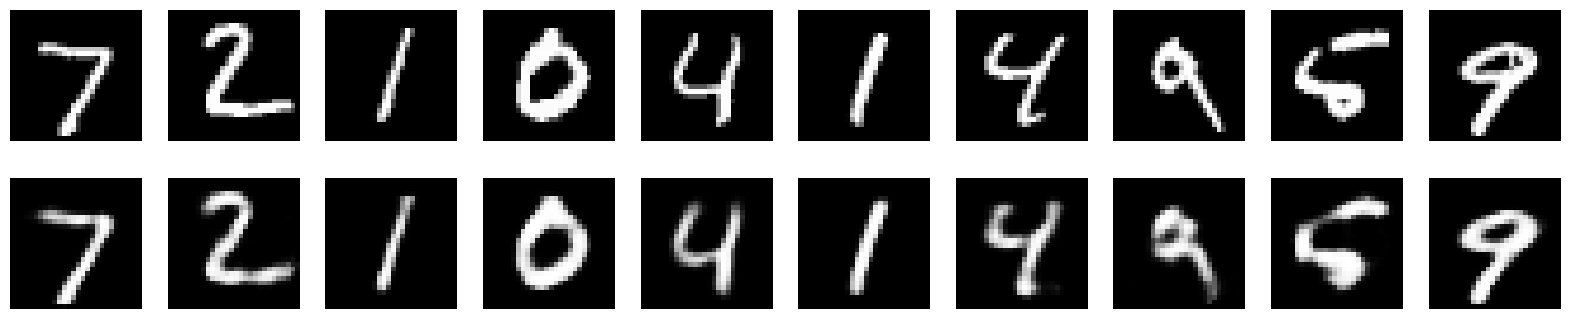

In [6]:
n = 10

plt.figure(figsize=(20, 4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_ae[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()

In [7]:
latent_dim = 32

class Sampling(layers.Layer):

    def call(self, inputs):

        z_mean, z_log_var = inputs

        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(
            shape=(batch, dim)
        )

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

This implements:

$$ z = \mu + \sigma\epsilon $$

where:

μ = mean
σ = standard deviation
ε = random noise

VAE Encoder

In [8]:
encoder_inputs = layers.Input(shape=(784,))

x = layers.Dense(128, activation="relu")(encoder_inputs)
x = layers.Dense(64, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │    100,480 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      2,080 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │      2,080 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 32)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 112,896 (441.00 KB)

 Trainable params: 112,896 (441.00 KB)

 Non-trainable params: 0 (0.00 B)

VAE Decoder

In [9]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(64, activation="relu")(latent_inputs)
x = layers.Dense(128, activation="relu")(x)
decoder_outputs = layers.Dense(
    784,
    activation="sigmoid"
)(x)

decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,568 (435.81 KB)

 Trainable params: 111,568 (435.81 KB)

 Non-trainable params: 0 (0.00 B)

Create the VAE

In [13]:
class VAE(Model):

    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            # Encoder
            z_mean, z_log_var, z = self.encoder(data)

            # Decoder
            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.backend.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=1
                )
            )

            # KL Divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total loss
            total_loss = reconstruction_loss + kl_loss

        # Calculate gradients
        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        # Update weights
        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

In [14]:
vae = VAE(encoder, decoder)
vae = VAE(encoder, decoder)

vae.compile(
    optimizer=tf.keras.optimizers.Adam()
)

In [15]:
history_vae = vae.fit(
    x_train,
    epochs=20,
    batch_size=256
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - kl_loss: 11.4025 - loss: 170.7413 - reconstruction_loss: 159.3388
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - kl_loss: 15.4638 - loss: 148.4636 - reconstruction_loss: 132.9998
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - kl_loss: 18.2458 - loss: 134.8499 - reconstruction_loss: 116.6041
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - kl_loss: 19.4578 - loss: 134.1964 - reconstruction_loss: 114.7385
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - kl_loss: 19.5697 - loss: 124.6271 - reconstruction_loss: 105.0574
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - kl_loss: 19.5082 - loss: 122.2488 - reconstruction_loss: 102.7406
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - kl_loss: 20.7572 - loss: 122.6892 - reconstruction_loss: 101.9320
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - kl_loss: 20.5786 - loss: 119.0576 - reconstruction_loss: 98.4790
Epoch 9/20
235/235 ━━━━━━━━━━━━━━

In [16]:
z_mean, z_log_var, z = encoder.predict(x_test)

reconstructed_vae = decoder.predict(z)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


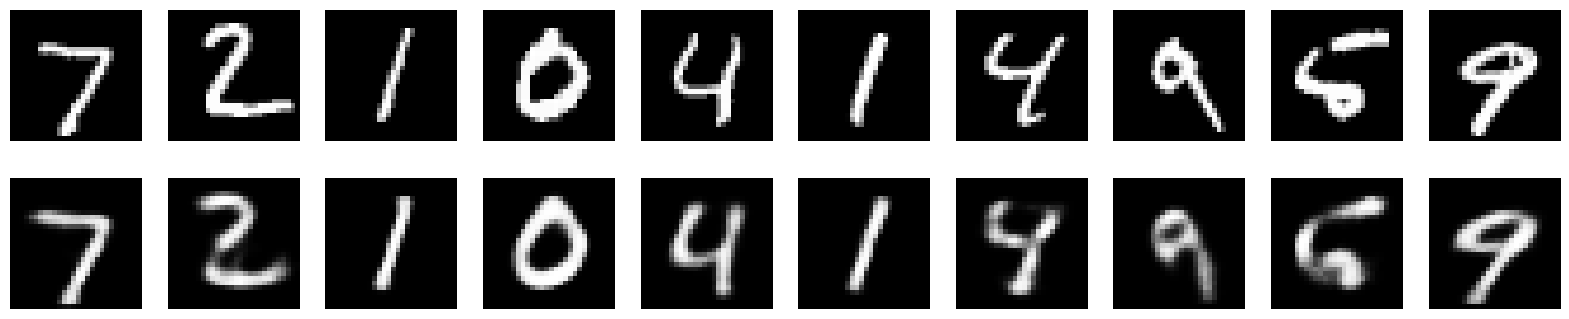

In [17]:
n = 10

plt.figure(figsize=(20, 4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # VAE reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(
        reconstructed_vae[i].reshape(28, 28),
        cmap="gray"
    )
    plt.axis("off")

plt.show()

In [18]:
random_latent_vectors = np.random.normal(
    size=(10, latent_dim)
)

generated_images = decoder.predict(
    random_latent_vectors
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


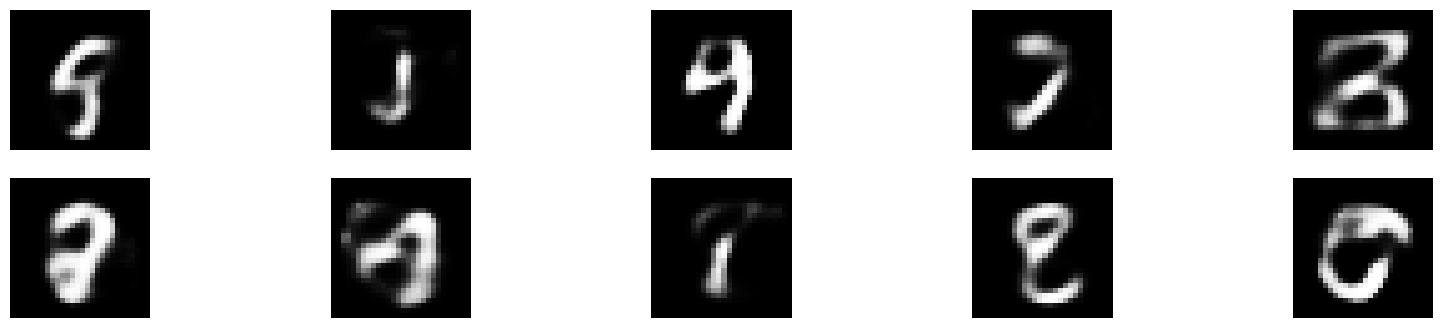

In [19]:
plt.figure(figsize=(20, 4))

for i in range(10):

    ax = plt.subplot(2, 5, i + 1)

    plt.imshow(
        generated_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")

plt.show()

comparisson
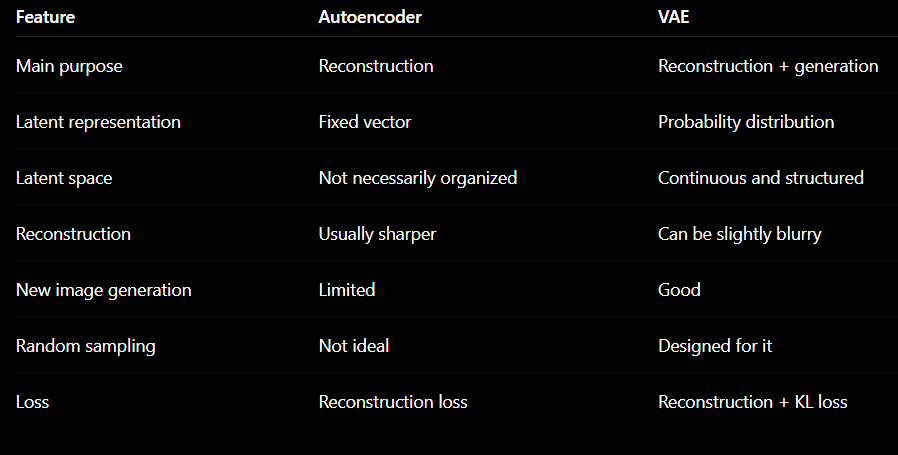

Reconstruction

The normal Autoencoder will generally produce sharper reconstructed images because its main objective is minimizing reconstruction error.

The VAE may produce slightly blurrier images because it also tries to keep its latent space smooth and well-structured.

Generation

The VAE is more suitable for generating new images because its latent space follows a probability distribution.

The Autoencoder does not naturally provide such a structured latent space, so random sampling from it may not produce meaningful images.

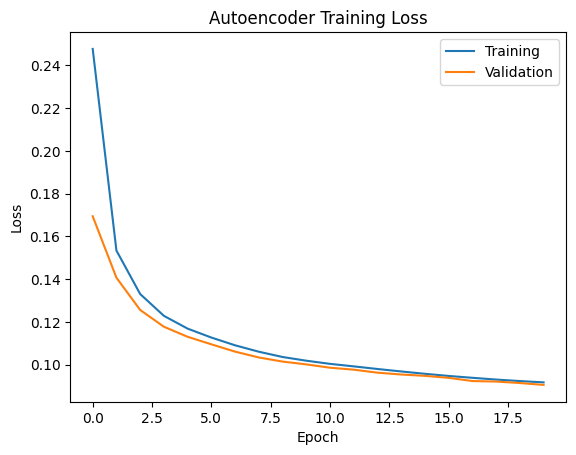

In [20]:
plt.plot(history_ae.history["loss"])
plt.plot(history_ae.history["val_loss"])

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training", "Validation"])
plt.show()

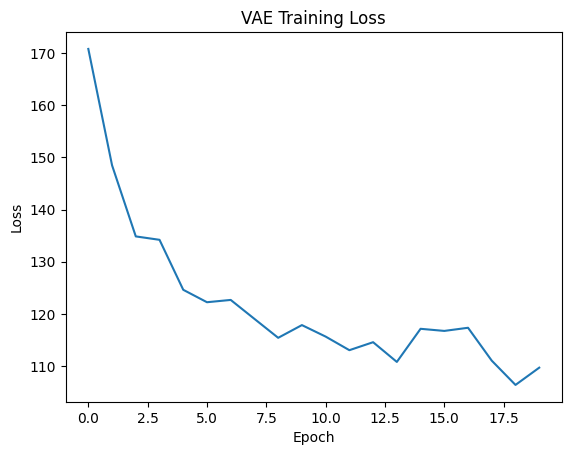

In [21]:
plt.plot(history_vae.history["loss"])

plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

The Autoencoder and Variational Autoencoder were successfully implemented using the MNIST dataset. The Autoencoder produced good-quality reconstructed images because it focuses mainly on minimizing reconstruction error. The Variational Autoencoder also reconstructed the images successfully, but its outputs may be slightly blurrier due to the probabilistic nature of its latent space.

The VAE provided an additional advantage: it could generate new digit-like images by randomly sampling points from its latent space. Therefore, the Autoencoder is mainly useful for tasks such as image reconstruction and feature compression, while the VAE is useful for both reconstruction and image generation.

Overall, both models were able to learn meaningful representations of handwritten digits, with the VAE providing a more structured latent space suitable for generative tasks.
